## Viken KHATCHERIAN
## Formation AI Engineer
## Openclassrooms
## Projet 6 : initiez-vous au MLOps partie (1/2)
## Notebook 4 : 04_tracking_opt_hyperpar_model_seuil_mlflow_p6_vk
### ETAPE 4 : Optimiser les hyperparamètres et le seuil métier + tracking des expériences avec mlflow

In [24]:
# Importer les bibliothèques
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.base import clone

import mlflow
import mlflow.sklearn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

In [25]:
# Charger les données 
X_train = pd.read_parquet("X_train_ml.parquet")
y_train = pd.read_parquet("y_train_ml.parquet").squeeze()

print(X_train.shape, y_train.shape)
print(y_train.value_counts(normalize=True))

(307511, 250) (307511,)
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [26]:
# Configuration de mlflow
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("P06_LightGBM_optimized")

<Experiment: artifact_location='file:///mnt/projects/ai_engineer_projects/P06/mlruns/7', creation_time=1780678827745, experiment_id='7', last_update_time=1780678827745, lifecycle_stage='active', name='P06_LightGBM_optimized', tags={}, trace_location=None, workspace='default'>

In [27]:
# Fonction de coût métier
def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return 10 * fn + 1 * fp

In [28]:
# Probabilités out of fold pour la recherche du meilleur seuil de décision (sans data leakage)
def oof_predictions(model, X, y, cv):
    oof = np.zeros(len(y))

    for train_idx, val_idx in cv.split(X, y):

        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr = y.iloc[train_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)

        oof[val_idx] = m.predict_proba(X_val)[:, 1]

    return oof

In [29]:
# Optimisation du seuil de décision
def optimize_threshold(y_true, y_prob):

    thresholds = np.linspace(0.05, 0.95, 50)

    costs = []
    f1s = []

    for t in thresholds:
        preds = (y_prob >= t).astype(int)

        costs.append(business_cost(y_true, preds))
        f1s.append(f1_score(y_true, preds))

    best_idx = np.argmin(costs)

    return thresholds[best_idx], costs, f1s, thresholds

In [30]:
# Setup du StratifierKold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [31]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 80),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 80),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),

        "scale_pos_weight": (len(y_train) - sum(y_train)) / sum(y_train),

        # stabilité CPU
        "n_jobs": 8,
        "random_state": 42,
        "verbose": -1
    }

    model = LGBMClassifier(**params)

    auc_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict_proba(X_val)[:, 1]

        auc_scores.append(roc_auc_score(y_val, preds))

    return np.mean(auc_scores)


In [32]:
# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

best_params = study.best_params
print(best_params)


[I 2026-06-05 19:34:24,270] A new study created in memory with name: no-name-60c41827-11df-4467-8f1a-ffb1aaa4c835
[I 2026-06-05 19:34:54,313] Trial 0 finished with value: 0.7808010681193885 and parameters: {'n_estimators': 584, 'learning_rate': 0.030126930617779664, 'num_leaves': 56, 'max_depth': 10, 'min_child_samples': 72, 'subsample': 0.9478118206147932, 'colsample_bytree': 0.7874551159459962}. Best is trial 0 with value: 0.7808010681193885.
[I 2026-06-05 19:35:12,737] Trial 1 finished with value: 0.7792882856751434 and parameters: {'n_estimators': 305, 'learning_rate': 0.02971151097529983, 'num_leaves': 48, 'max_depth': 8, 'min_child_samples': 78, 'subsample': 0.8099570481009501, 'colsample_bytree': 0.9422753131068089}. Best is trial 0 with value: 0.7808010681193885.
[I 2026-06-05 19:35:22,355] Trial 2 finished with value: 0.7503904904338807 and parameters: {'n_estimators': 285, 'learning_rate': 0.011345167196345696, 'num_leaves': 55, 'max_depth': 3, 'min_child_samples': 39, 'subsa

{'n_estimators': 499, 'learning_rate': 0.03065649583403631, 'num_leaves': 35, 'max_depth': 10, 'min_child_samples': 62, 'subsample': 0.8785687807677668, 'colsample_bytree': 0.765469960781505}


2026/06/05 20:11:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/05 20:11:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/05 20:11:11 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run LightGBM_optimized_business at: http://127.0.0.1:5000/#/experiments/7/runs/10f1e9a4f4b24572908256aaf22ad330
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


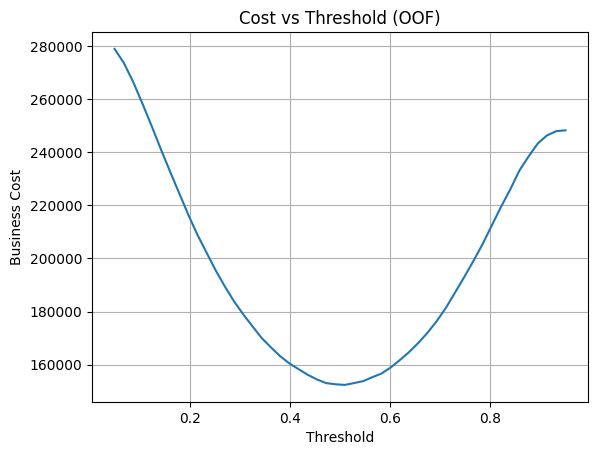

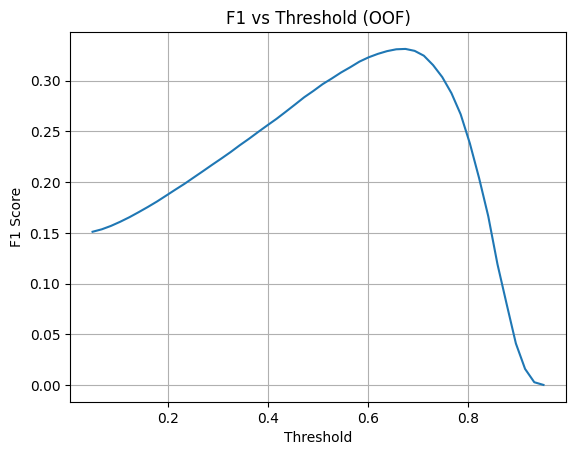

In [34]:
# =========================
# FINAL MLflow RUN - STEP 4
# =========================
with mlflow.start_run(run_name="LightGBM_optimized_business"):

    # =========================
    # SCALE POS WEIGHT (déséquilibre classes)
    # =========================
    scale_pos = (len(y_train) - sum(y_train)) / sum(y_train)

    # =========================
    # MODEL
    # =========================
    best_model = LGBMClassifier(
        **best_params,
        scale_pos_weight=scale_pos,
        random_state=42,
        n_jobs=8,
        verbose=-1
    )

    # =========================
    # TAGS (UI MLflow)
    # =========================
    mlflow.set_tags({
        "project": "P06",
        "stage": "optimization",
        "model": "LightGBM",
        "selection_method": "Optuna + CV + business cost",
        "imbalance_handling": "scale_pos_weight",
        "cv_strategy": "StratifiedKFold",
        "primary_metric": "business_cost_oof"
    })

    # =========================
    # PARAMS (TRACEABILITÉ)
    # =========================
    mlflow.log_params(best_params)
    mlflow.log_param("scale_pos_weight", scale_pos)
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("optuna_best_trial", study.best_trial.number)
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("n_samples", len(X_train))

    # =========================
    # CV SCORE (AUC)
    # =========================
    aucs = []

    for train_idx, val_idx in cv.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # IMPORTANT: modèle indépendant par fold (anti leakage)
        fold_model = LGBMClassifier(
            **best_params,
            scale_pos_weight=scale_pos,
            random_state=42,
            n_jobs=8,
            verbose=-1
        )

        fold_model.fit(X_tr, y_tr)
        preds = fold_model.predict_proba(X_val)[:, 1]

        aucs.append(roc_auc_score(y_val, preds))

    auc_mean = np.mean(aucs)

    # =========================
    # OOF PREDICTIONS (ANTI LEAKAGE)
    # =========================
    oof = oof_predictions(best_model, X_train, y_train, cv)

    # =========================
    # THRESHOLD OPTIMIZATION (BUSINESS)
    # =========================
    best_threshold, costs, f1s, thresholds = optimize_threshold(y_train, oof)

    # =========================
    # BUSINESS COST FINAL (OOF ONLY → NO LEAKAGE)
    # =========================
    final_pred_oof = (oof >= best_threshold).astype(int)
    final_cost = business_cost(y_train, final_pred_oof)

    # =========================
    # MLflow METRICS (IMPORTANT POUR CHAMPION SELECTION)
    # =========================
    mlflow.log_metric("cv_auc_mean", auc_mean)
    mlflow.log_metric("business_cost_oof", final_cost)
    mlflow.log_metric("best_threshold", best_threshold)

    # métriques secondaires utiles UI
    mlflow.log_metric("cost_reduction_signal", -final_cost)
    mlflow.log_metric("n_features", X_train.shape[1])
    mlflow.log_metric("n_samples", len(X_train))

    # =========================
    # ARTIFACTS (CURVES MÉTIER)
    # =========================
    plt.figure()
    plt.plot(thresholds, costs)
    plt.xlabel("Threshold")
    plt.ylabel("Business Cost")
    plt.title("Cost vs Threshold (OOF)")
    plt.grid()
    plt.savefig("cost_vs_threshold.png")
    mlflow.log_artifact("cost_vs_threshold.png")

    plt.figure()
    plt.plot(thresholds, f1s)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 vs Threshold (OOF)")
    plt.grid()
    plt.savefig("f1_vs_threshold.png")
    mlflow.log_artifact("f1_vs_threshold.png")

    # =========================
    # FINAL MODEL TRAIN (READY FOR REGISTRY)
    # =========================
    best_model.fit(X_train, y_train)

    mlflow.sklearn.log_model(
        best_model,
        artifact_path="model"
    )

- L’étape 3 a permis de sélectionner LightGBM comme meilleur compromis performance / coût métier.
- L’étape 4 a ensuite optimisé ce modèle via Optuna et ajustement du seuil de décision basé sur les probabilités out-of-fold afin de minimiser le coût métier (FN fortement pénalisés).”

2026/06/05 19:56:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/05 19:56:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/05 19:56:38 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run LightGBM_optimized_business at: http://127.0.0.1:5000/#/experiments/7/runs/8c109c800efe4f85bb96f4a1ddfc1f6c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


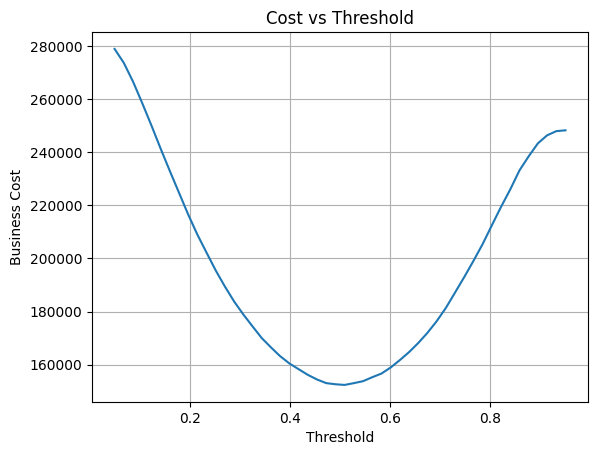

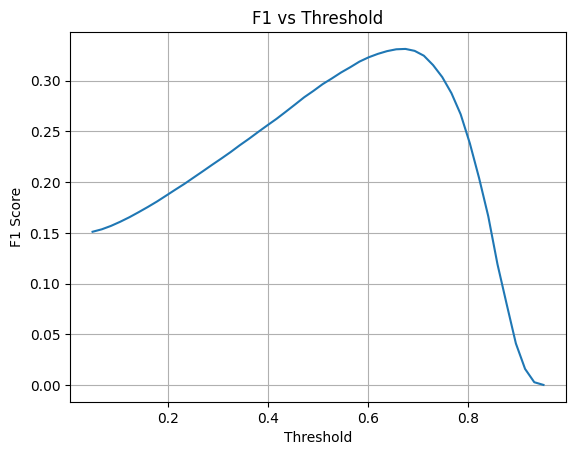

In [33]:
# =========================
# FINAL MLflow RUN
# =========================
with mlflow.start_run(run_name="LightGBM_optimized_business"):

    # =========================
    # MODEL (BEST PARAMS)
    # =========================
    scale_pos = (len(y_train) - sum(y_train)) / sum(y_train)

    best_model = LGBMClassifier(
        **best_params,
        scale_pos_weight=scale_pos,
        random_state=42,
        n_jobs=8,
        verbose=-1
    )

    # =========================
    # TAGS (IMPORTANT MLflow UI)
    # =========================
    mlflow.set_tags({
        "project": "P06",
        "stage": "optimization",
        "model": "LightGBM",
        "selection_method": "Optuna + CV + business cost",
        "imbalance_handling": "scale_pos_weight",
        "cv_strategy": "StratifiedKFold",
    })

    # =========================
    # PARAMS (TRACEABILITÉ)
    # =========================
    mlflow.log_params(best_params)
    mlflow.log_param("scale_pos_weight", scale_pos)
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("optuna_best_trial", study.best_trial.number)

    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("n_samples", len(X_train))

    # =========================
    # CV SCORE (AUC)
    # =========================
    aucs = []

    for train_idx, val_idx in cv.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # IMPORTANT: nouveau modèle par fold (anti contamination)
        fold_model = LGBMClassifier(
            **best_params,
            scale_pos_weight=scale_pos,
            random_state=42,
            n_jobs=8,
            verbose=-1
        )

        fold_model.fit(X_tr, y_tr)
        preds = fold_model.predict_proba(X_val)[:, 1]

        aucs.append(roc_auc_score(y_val, preds))

    auc_mean = np.mean(aucs)

    # =========================
    # OOF + THRESHOLD
    # =========================
    oof = oof_predictions(best_model, X_train, y_train, cv)

    best_threshold, costs, f1s, thresholds = optimize_threshold(y_train, oof)

    # =========================
    # FINAL BUSINESS COST (OOF - NO LEAKAGE)
    # =========================
    final_pred_oof = (oof >= best_threshold).astype(int)
    final_cost = business_cost(y_train, final_pred_oof)

    # =========================
    # MLflow METRICS
    # =========================
    mlflow.log_metric("cv_auc_mean", auc_mean)
    mlflow.log_metric("business_cost_oof", final_cost)
    mlflow.log_metric("best_threshold", best_threshold)
    mlflow.log_metric("cost_reduction_signal", -final_cost)
    mlflow.log_metric("n_features", X_train.shape[1])
    mlflow.log_metric("n_samples", len(X_train))

    # =========================
    # ARTIFACTS
    # =========================

    plt.figure()
    plt.plot(thresholds, costs)
    plt.xlabel("Threshold")
    plt.ylabel("Business Cost")
    plt.title("Cost vs Threshold")
    plt.grid()
    plt.savefig("cost_vs_threshold.png")
    mlflow.log_artifact("cost_vs_threshold.png")

    plt.figure()
    plt.plot(thresholds, f1s)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 vs Threshold")
    plt.grid()
    plt.savefig("f1_vs_threshold.png")
    mlflow.log_artifact("f1_vs_threshold.png")

    # =========================
    # MODEL REGISTRY READY
    # =========================
    mlflow.sklearn.log_model(
        best_model,
        artifact_path="model"
    )

In [23]:
# Final mlflow run
with mlflow.start_run(run_name="LightGBM_optimized_business"):

    # modèle final
    best_model = LGBMClassifier(
    **best_params,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
    random_state=42,
    n_jobs=8,
    verbose=-1
)

    # =========================
    # CV SCORE (AUC)
    # =========================
    aucs = []

    for train_idx, val_idx in cv.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        best_model.fit(X_tr, y_tr)
        preds = best_model.predict_proba(X_val)[:, 1]

        aucs.append(roc_auc_score(y_val, preds))

    auc_mean = np.mean(aucs)


    # =========================
    # OOF + THRESHOLD
    # =========================
    oof = oof_predictions(best_model, X_train, y_train, cv)

    best_threshold, costs, f1s, thresholds = optimize_threshold(y_train, oof)


    # =========================
    # FINAL FIT
    # =========================
    final_pred_oof = (oof >= best_threshold).astype(int)

    final_cost = business_cost(y_train, final_pred_oof)


    # =========================
    # MLflow LOGS
    # =========================
    mlflow.log_params(best_params)

    mlflow.log_metric("cv_auc_mean", auc_mean)
    mlflow.log_metric("business_cost_train", final_cost)
    mlflow.log_metric("best_threshold", best_threshold)
    mlflow.log_metric("n_features", X_train.shape[1])
    mlflow.log_metric("n_samples", len(X_train))


    # =========================
    # ARTIFACTS
    # =========================
    plt.figure()
    plt.plot(thresholds, costs)
    plt.xlabel("Threshold")
    plt.ylabel("Business Cost")
    plt.title("Cost vs Threshold")
    plt.grid()
    plt.savefig("cost_vs_threshold.png")
    mlflow.log_artifact("cost_vs_threshold.png")

    plt.figure()
    plt.plot(thresholds, f1s)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 vs Threshold")
    plt.grid()
    plt.savefig("f1_vs_threshold.png")
    mlflow.log_artifact("f1_vs_threshold.png")


    # =========================
    # MODEL REGISTRY READY
    # =========================
    mlflow.sklearn.log_model(
        best_model,
        artifact_path="model"
    )